# Data Exploratory Analysis

Questions addressed:
1. Department-wise performance.
2. Important relationships between employee attributes and performance.
3. Interactions among the leading factors.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DATASET = r"C:\\Users\\karth\Desktop\\cds_iabac\\data\\raw\\INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls"
df = pd.read_excel(DATASET)
print("dataset loaded succesfully")
print("shape of dataset", df.shape)
display(df.head())

dataset loaded succesfully
shape of dataset (1200, 28)


,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [4]:
print("No of rows", df.shape[0])
print("No of columns", df.shape[1])

print("column names: \n", df.columns.tolist())
print("Data Types: \n", df.dtypes)

print("Missing values: \n", df.isnull().sum())
print("Duplicates: \n", df.duplicated().sum())

No of rows 1200
No of columns 28
column names: 
 ['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime', 'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition', 'PerformanceRating']
Data Types: 
 EmpNumber                       object
Age                              int64
Gender                          object
EducationBackground             object
MaritalStatus                   object
EmpDepartment                   object
EmpJobRole                      object
BusinessTravelFrequency         object
DistanceFromHome               

### DESCRIPTIVE STATISTICS

In [5]:
print("Numerical variable summary")
df.describe().T

Numerical variable summary


,count,mean,std,min,25%,50%,75%,max
Age,1200.0,36.918333,9.087289,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1200.0,9.165833,8.176636,1.0,2.0,7.0,14.0,29.0
EmpEducationLevel,1200.0,2.892500,1.044120,1.0,2.0,3.0,4.0,5.0
EmpEnvironmentSatisfaction,1200.0,2.715833,1.090599,1.0,2.0,3.0,4.0,4.0
EmpHourlyRate,1200.0,65.981667,20.211302,30.0,48.0,66.0,83.0,100.0
EmpJobInvolvement,1200.0,2.731667,0.707164,1.0,2.0,3.0,3.0,4.0
EmpJobLevel,1200.0,2.067500,1.107836,1.0,1.0,2.0,3.0,5.0
EmpJobSatisfaction,1200.0,2.732500,1.100888,1.0,2.0,3.0,4.0,4.0
NumCompaniesWorked,1200.0,2.665000,2.469384,0.0,1.0,2.0,4.0,9.0
EmpLastSalaryHikePercent,1200.0,15.222500,3.625918,11.0,12.0,14.0,18.0,25.0


In [6]:
print("performance rating distribution")
display(df["PerformanceRating"].value_counts().sort_index().to_frame("Employee count"))

print("percentage distribution")
display((df["PerformanceRating"].value_counts(normalize=True).sort_index()*100).round(2).to_frame("percentage"))


performance rating distribution


,Employee count
PerformanceRating,
2,194
3,874
4,132


percentage distribution


,percentage
PerformanceRating,
2,16.17
3,72.83
4,11.00


### Performance Rating Visualization

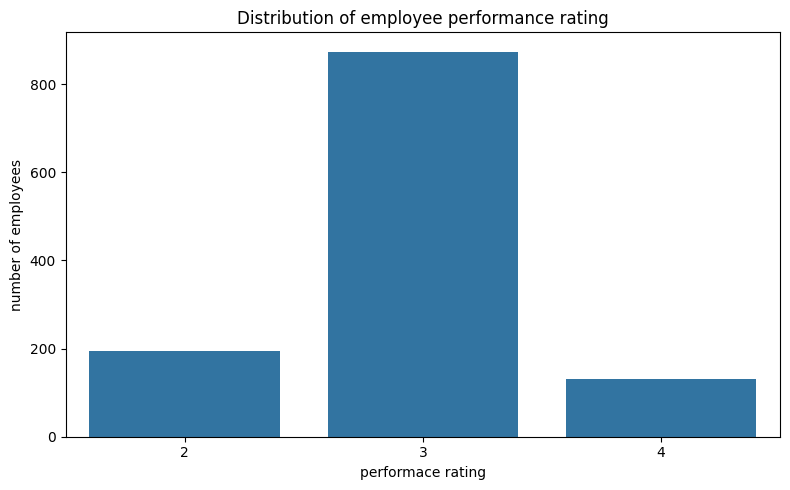

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["PerformanceRating"])
plt.title("Distribution of employee performance rating")
plt.xlabel("performace rating")
plt.ylabel("number of employees")
plt.tight_layout()
plt.show()

### Department-wise Performance

In [8]:
department_performance = df.groupby("EmpDepartment")["PerformanceRating"].agg(Employee_count="count", average_performance="mean")
department_performance.round(2)

,Employee_count,average_performance
EmpDepartment,,
Data Science,20,3.05
Development,361,3.09
Finance,49,2.78
Human Resources,54,2.93
Research & Development,343,2.92
Sales,373,2.86


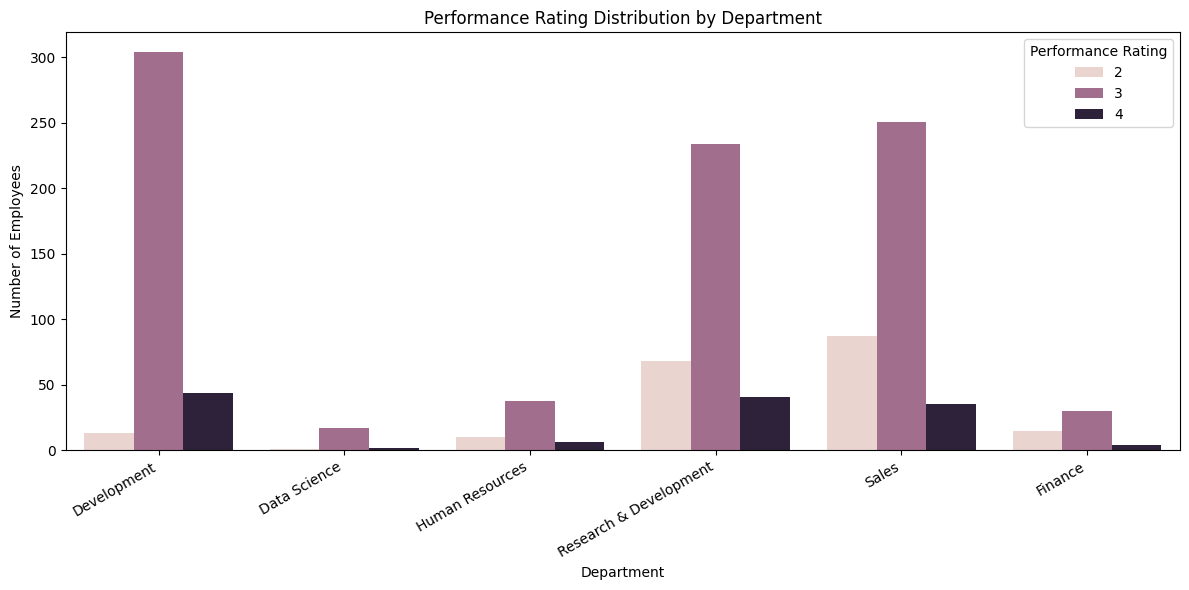

In [9]:
department_order = (
    df.groupby("EmpDepartment")["PerformanceRating"]
    .mean()
    .sort_values(ascending=False)
    .index
)
plt.figure(figsize=(12, 6))
sns.countplot(data=df,x="EmpDepartment",hue="PerformanceRating",order=department_order)
plt.title("Performance Rating Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Performance Rating")
plt.tight_layout()
plt.show()

## Numerical Feature Analysis

In [10]:
numerical_col = df.select_dtypes(include=np.number).columns.tolist()
numerical_col 

['Age',
 'DistanceFromHome',
 'EmpEducationLevel',
 'EmpEnvironmentSatisfaction',
 'EmpHourlyRate',
 'EmpJobInvolvement',
 'EmpJobLevel',
 'EmpJobSatisfaction',
 'NumCompaniesWorked',
 'EmpLastSalaryHikePercent',
 'EmpRelationshipSatisfaction',
 'TotalWorkExperienceInYears',
 'TrainingTimesLastYear',
 'EmpWorkLifeBalance',
 'ExperienceYearsAtThisCompany',
 'ExperienceYearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'PerformanceRating']

In [12]:
correlations = df[numerical_col].corr(method='spearman')["PerformanceRating"].drop("PerformanceRating").sort_values(ascending=False)
correlations

EmpEnvironmentSatisfaction      0.396601
EmpLastSalaryHikePercent        0.273686
EmpWorkLifeBalance              0.113750
NumCompaniesWorked              0.038254
EmpEducationLevel               0.015318
EmpJobSatisfaction              0.005482
TrainingTimesLastYear           0.001250
EmpJobInvolvement              -0.010690
EmpRelationshipSatisfaction    -0.021912
Age                            -0.034796
DistanceFromHome               -0.037577
EmpHourlyRate                  -0.044846
TotalWorkExperienceInYears     -0.074347
EmpJobLevel                    -0.080804
ExperienceYearsAtThisCompany   -0.132478
YearsWithCurrManager           -0.135021
ExperienceYearsInCurrentRole   -0.166069
YearsSinceLastPromotion        -0.269732
Name: PerformanceRating, dtype: float64

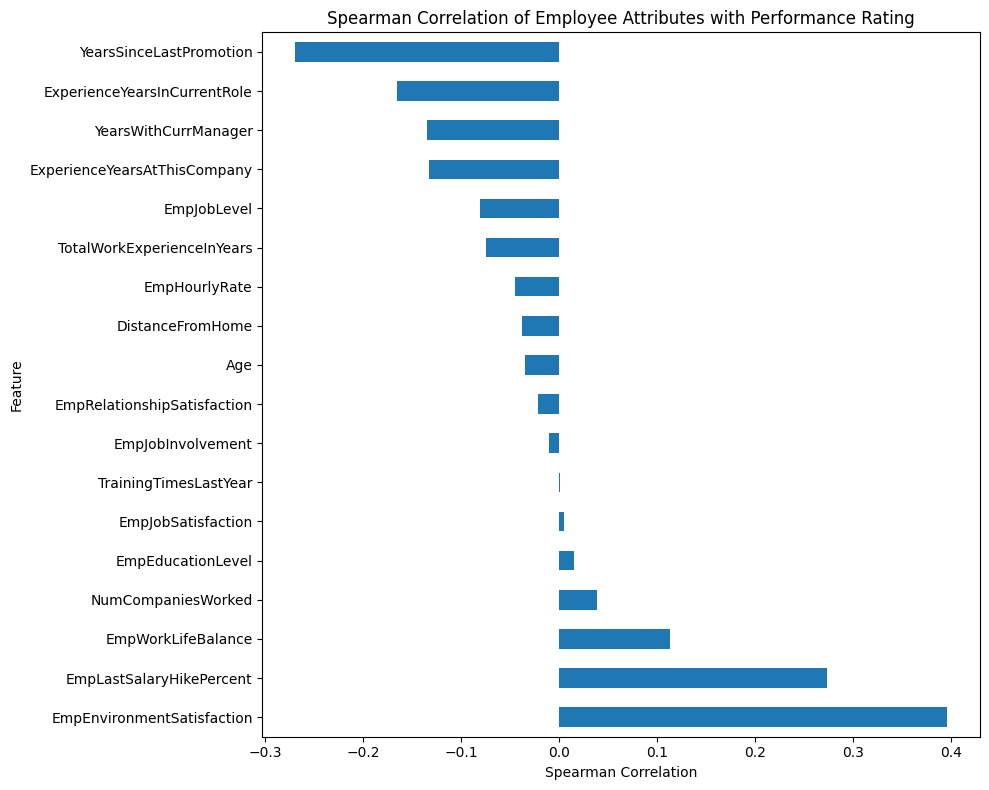

In [14]:
plt.figure(figsize=(10, 8))
correlations.plot(kind="barh")
plt.title(
    "Spearman Correlation of Employee Attributes with Performance Rating"
)

plt.xlabel("Spearman Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Visualize correlations

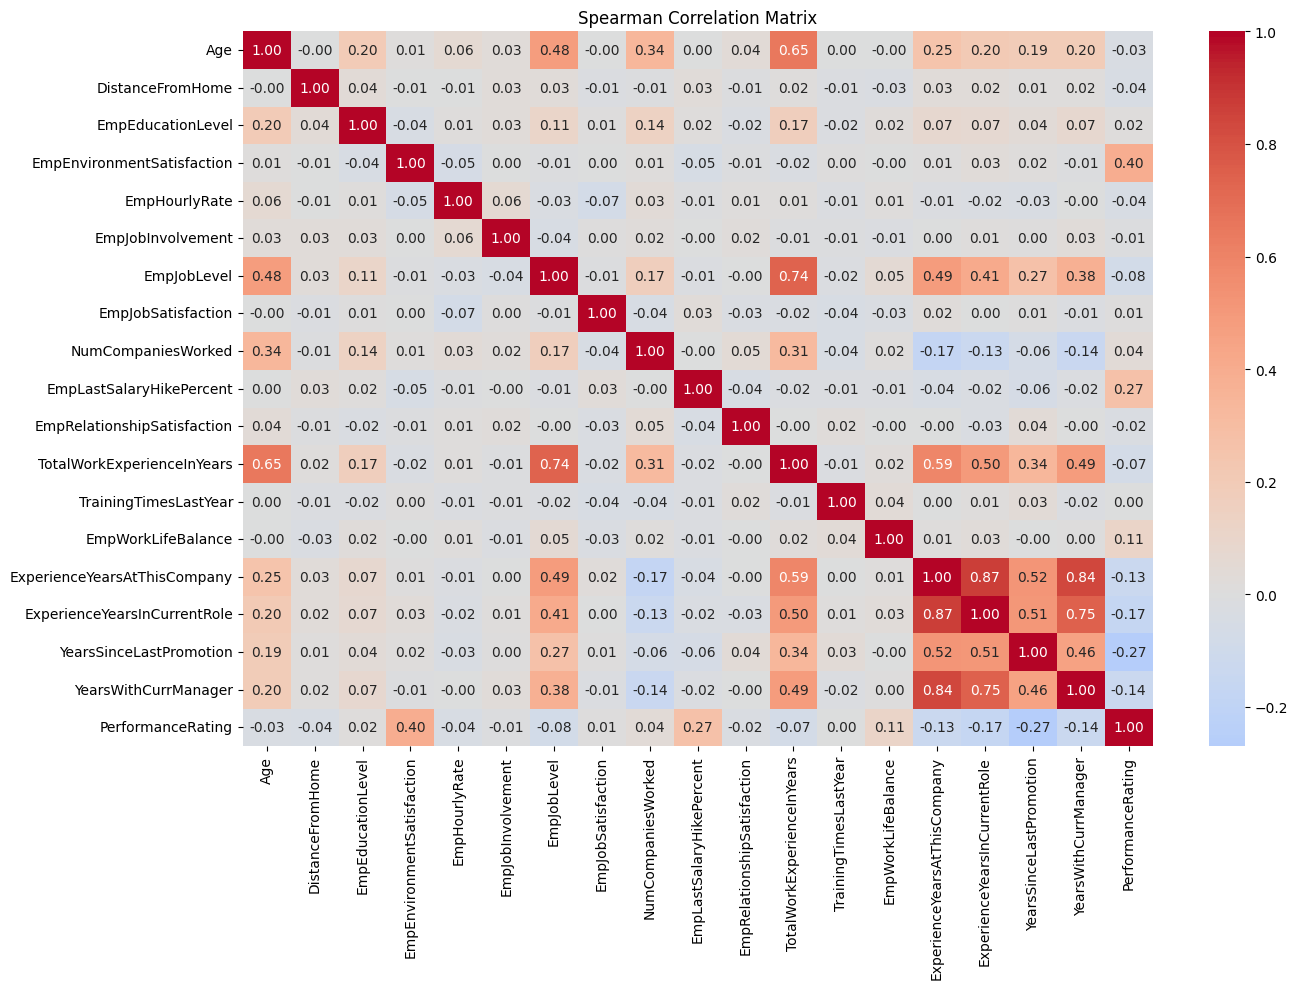

In [21]:
spearman_matrix = df[numerical_col].corr(method="spearman")
plt.figure(figsize=(14, 10))
sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()